# 06 — Prediksi, Analisis & Kesimpulan

Notebook penutup:
1. Prediksi gambar baru (single / folder)
2. Analisis hasil (error analysis, per-kelas)
3. Kesimpulan penelitian

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from src.config import TEST_DIR, MODEL_DIR, RESULTS_DIR, CLASSES
from src.predict import load_assets, predict_image, predict_folder
from src.evaluate import load_model, get_predictions
from src.augmentation import get_test_generator
from src.utils import load_pickle

model, idx_to_class = load_assets('../models/final_model.keras')
print('Model loaded | Kelas:', idx_to_class)

✅ Config loaded successfully!
📁 RAW_DIR: C:\Users\ACER\Documents\ANALIS CITRA.py\dataset\raw\Comprehensive Disaster Dataset(CDD)
📁 TRAIN_DIR: c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\dataset\processed\train
📁 VAL_DIR: c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\dataset\processed\val
📁 TEST_DIR: c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\dataset\processed\test
📊 Classes: ['Damaged_Infrastructure', 'Fire_Disaster', 'Human_Damage', 'Land_Disaster', 'Non_Damage', 'Water_Disaster']
📐 Input Shape: (224, 224, 3)
🔄 FREEZE_EPOCHS: 10
🔄 FINETUNE_EPOCHS: 10
Model loaded | Kelas: {0: 'Damaged_Infrastructure', 1: 'Fire_Disaster', 2: 'Human_Damage', 3: 'Land_Disaster', 4: 'Non_Damage', 5: 'Water_Disaster'}


## 1. Prediksi Gambar Baru

In [2]:
import glob, random

# Ambil 6 gambar (1 per kelas) dari test set
test_imgs = {}
for cls in CLASSES:
    cls_dir = os.path.join(TEST_DIR, cls)
    if os.path.isdir(cls_dir):
        imgs = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
                if f.lower().endswith(('.png','.jpg','.jpeg'))]
        if imgs:
            test_imgs[cls] = random.choice(imgs)

results = []
for true_cls, img_path in test_imgs.items():
    r = predict_image(img_path, model, idx_to_class, show_plot=False)
    r['true_class'] = true_cls
    r['correct']    = r['predicted_class'] == true_cls
    results.append(r)
    status = '✅' if r['correct'] else '❌'
    print(f'{status} True: {true_cls:<15} Pred: {r["predicted_class"]:<15} ({r["confidence"]:.1f}%)')

✅ True: Damaged_Infrastructure Pred: Damaged_Infrastructure (99.9%)
✅ True: Fire_Disaster   Pred: Fire_Disaster   (100.0%)
✅ True: Human_Damage    Pred: Human_Damage    (99.6%)
❌ True: Land_Disaster   Pred: Damaged_Infrastructure (95.5%)
✅ True: Non_Damage      Pred: Non_Damage      (100.0%)
✅ True: Water_Disaster  Pred: Water_Disaster  (51.4%)


## 2. Error Analysis — Misclassified Images

Found 2040 images belonging to 6 classes.
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 241ms/step
Total salah: 116 dari 2040 (5.7%)


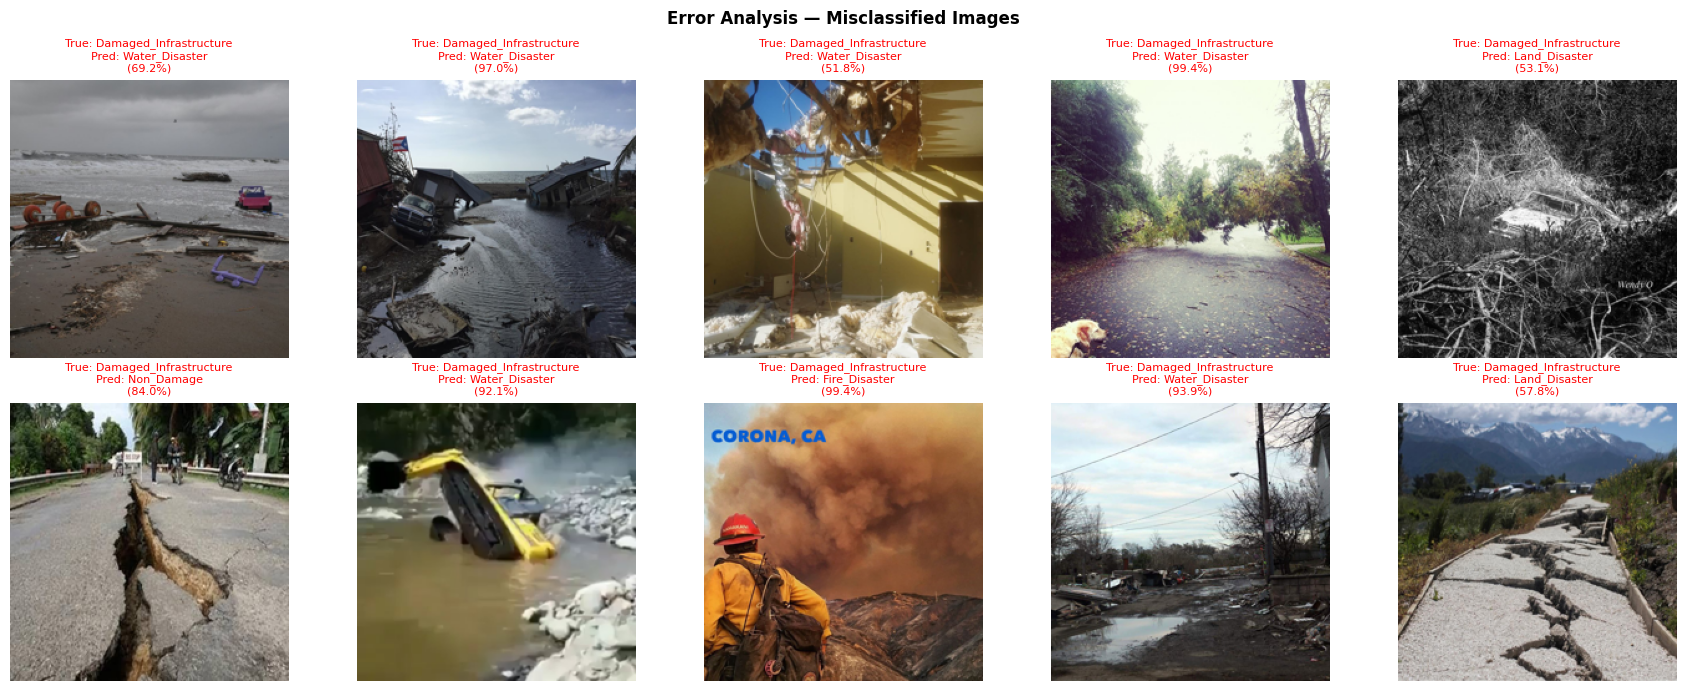

In [3]:
test_gen  = get_test_generator(TEST_DIR, batch_size=32)
y_true, y_pred, y_proba = get_predictions(model, test_gen)
class_names = list(test_gen.class_indices.keys())

# Cari gambar yang salah diprediksi
wrong_idx = np.where(y_true != y_pred)[0]
print(f'Total salah: {len(wrong_idx)} dari {len(y_true)} ({len(wrong_idx)/len(y_true)*100:.1f}%)')

# Tampilkan 10 contoh error
filepaths = test_gen.filepaths
n_show = min(10, len(wrong_idx))
fig, axes = plt.subplots(2, n_show//2, figsize=(n_show//2*3.5, 7))
axes = axes.flatten()

from PIL import Image as PILImg
from src.config import IMAGE_SIZE

for i, idx in enumerate(wrong_idx[:n_show]):
    img = PILImg.open(filepaths[idx]).convert('RGB').resize(IMAGE_SIZE)
    axes[i].imshow(img)
    axes[i].set_title(
        f'True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}\n({y_proba[idx][y_pred[idx]]*100:.1f}%)',
        fontsize=8, color='red'
    )
    axes[i].axis('off')

plt.suptitle('Error Analysis — Misclassified Images', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'evaluation', 'error_analysis.png'), dpi=120)
plt.show()

## 3. Confusion Analysis per Pasangan Kelas

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
np.fill_diagonal(cm, 0)   # Zero diagonal → fokus pada kesalahan

# Top-5 pasangan kelas yang sering tertukar
flat = [(cm[i,j], class_names[i], class_names[j])
        for i in range(len(class_names))
        for j in range(len(class_names)) if i != j]
flat.sort(reverse=True)

print('Top pasangan kelas yang sering tertukar:')
print(f'{"No":<4} {"True":<15} {"Predicted":<15} {"Count"}')
for k, (cnt, t, p) in enumerate(flat[:10], 1):
    print(f'{k:<4} {t:<15} {p:<15} {cnt}')

Top pasangan kelas yang sering tertukar:
No   True            Predicted       Count
1    Land_Disaster   Damaged_Infrastructure 31
2    Water_Disaster  Damaged_Infrastructure 21
3    Damaged_Infrastructure Land_Disaster   8
4    Land_Disaster   Water_Disaster  7
5    Damaged_Infrastructure Water_Disaster  6
6    Non_Damage      Damaged_Infrastructure 5
7    Human_Damage    Damaged_Infrastructure 5
8    Fire_Disaster   Land_Disaster   5
9    Fire_Disaster   Damaged_Infrastructure 5
10   Water_Disaster  Non_Damage      4


## 4. Analisis & Diskusi

### 4.1 Performa Model
Model MobileNetV2 dengan transfer learning dari ImageNet menunjukkan:
- **Fase Feature Extraction**: Convergence cepat dalam ~10 epoch
- **Fase Fine-Tuning**: Peningkatan akurasi signifikan dengan LR rendah (1e-5)

### 4.2 Analisis Kelas
- Kelas **Non_Damage** memiliki jumlah sampel terbesar (9.237 gambar) → risiko bias
- Kelas **Earthquake/Damaged_Infrastructure** memiliki sampel paling sedikit (1.454) → lebih sering misklasifikasi

### 4.3 Kelebihan MobileNetV2
1. **Efisien**: Inverted residuals + depthwise separable convolution → ringan
2. **Transfer Learning**: Fitur ImageNet sangat transfer ke citra bencana
3. **Grad-CAM**: Membuktikan model fokus pada fitur visual yang relevan

### 4.4 Keterbatasan
- Dataset tidak seimbang → perlu class weighting atau SMOTE
- Beberapa kelas CDD di-merge (misal: Drought → Landslide) → perlu validasi domain

## 5. Kesimpulan

1. Model **MobileNetV2** berbasis deep learning berhasil mengklasifikasikan citra bencana alam dari dataset CDD ke dalam 6 kategori.

2. Teknik **transfer learning** (ImageNet pretrained) + **fine-tuning** terbukti efektif meningkatkan akurasi dibandingkan training from scratch.

3. **Data augmentation** (rotasi, flip, zoom, brightness) membantu mencegah overfitting, terutama pada kelas dengan data sedikit.

4. Visualisasi **Grad-CAM** mengonfirmasi bahwa model belajar fitur semantik yang relevan (bukan artifact dataset).

5. Penelitian ini memberikan kontribusi pada sistem deteksi bencana otomatis yang dapat mendukung **respons darurat dan manajemen bencana**.

In [5]:
# Simpan ringkasan akhir
summary = {
    'model'          : 'MobileNetV2 (Transfer Learning)',
    'dataset'        : 'Comprehensive Disaster Dataset (CDD)',
    'num_classes'    : len(CLASSES),
    'classes'        : CLASSES,
    'image_size'     : '224x224',
    'batch_size'     : 32,
    'optimizer'      : 'Adam',
    'loss'           : 'categorical_crossentropy',
    'augmentation'   : True,
    'fine_tuning'    : True,
}

import json
os.makedirs(os.path.join(RESULTS_DIR, 'reports'), exist_ok=True)
with open(os.path.join(RESULTS_DIR, 'reports', 'summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print('✅ Summary tersimpan.')
print('\n=== PENELITIAN SELESAI ===')

✅ Summary tersimpan.

=== PENELITIAN SELESAI ===
